# PPTMixer: Detecting Genuine Multipartite Entanglement

Python implementation based on:
- B. Jungnitsch, T. Moroder and O. Gühne, Phys. Rev. Lett. 106, 190502 (2011)
- arXiv:1010.6049

This notebook demonstrates how to detect genuine multipartite entanglement using semidefinite programming.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from pptmixer import (partial_transpose, fdecwit, fpptwit, entmon,
                       ghz_state, w_state, bell_state, 
                       dicke_state, add_white_noise)

np.set_printoptions(precision=4, suppress=True)

## 1. Partial Transpose Basics

First, let's understand the partial transpose operation.

In [55]:
rho_bell = bell_state('phi+')
print("Bell state:")
print(rho_bell)

# Partial transpose with respect to first qubit
rho_pt = partial_transpose(rho_bell, [0, 1], [2, 2])
print("Partial transpose:")
print(rho_pt)

# Check eigenvalues
eigenvalues = np.linalg.eigvalsh(rho_pt)
print(f"Eigenvalues: {eigenvalues}")
print(f"Minimum eigenvalue: {min(eigenvalues):.4f}")
print("Negative eigenvalue indicates entanglement (PPT criterion)")

Bell state:
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]
Partial transpose:
[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Eigenvalues: [-0.5  0.5  0.5  0.5]
Minimum eigenvalue: -0.5000
Negative eigenvalue indicates entanglement (PPT criterion)


## 2. Two-Qubit Entanglement Detection

For two qubits, there's only one bipartition, so the test is equivalent to the PPT criterion.

In [56]:
# Test Bell state
print("Testing Bell state:")
min_val, W = fdecwit(rho_bell)
print(f"  Minimum value: {min_val:.3f}")
if min_val < 0:
    print("Entangled!")
    print(f"\nWitness W:")
    print(W)

Testing Bell state:
  Minimum value: -0.500
Entangled!

Witness W:
[[ 0. +0.j  0. +0.j  0. +0.j -0.5+0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [-0.5+0.j  0. +0.j  0. +0.j  0. +0.j]]


In [57]:
W_analytic = 0.5 * np.eye(4) - rho_bell
print("Analytic witness:")
print(W_analytic)
print(rf"\nTr(W\rho) = {np.trace(W_analytic @ rho_bell).real:.3f}")

Analytic witness:
[[ 0. +0.j  0. +0.j  0. +0.j -0.5+0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [-0.5+0.j  0. +0.j  0. +0.j  0. +0.j]]
\nTr(W\rho) = -0.500


## 3. Three-Qubit GHZ State

Now we test genuine multipartite entanglement in a 3-qubit system.

In [58]:
# Create 3-qubit GHZ state
rho_ghz3 = ghz_state(3)
print(rho_ghz3)

# Test with fully PPT witness
print("Testing with fdecwit:")
min_val, W = fdecwit(rho_ghz3)
print(f"Minimum value: {min_val:.6f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Testing with fdecwit:
Minimum value: -0.166667
Genuinely multipartite entangled!


## 4. Three-Qubit W State

In [59]:
# Create 3-qubit W state
rho_w3 = w_state(3)
print(rho_w3)

min_val, W = fdecwit(rho_w3)
print(f"\nMinimum value: {min_val:.6f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]]

Minimum value: -0.135966
Genuinely multipartite entangled!


## 5. White Noise Tolerance

Let's find how much white noise can be added while still detecting entanglement.

In [60]:
def find_noise_tolerance(rho, name="State", num_points=20):
    """Find the white noise tolerance for a state."""
    noise_levels = np.linspace(0, 1, num_points)
    min_vals = []
    
    for p in noise_levels:
        rho_noisy = add_white_noise(rho, p)
        min_val, _ = fdecwit(rho_noisy)
        min_vals.append(min_val)
    
    # Find threshold
    p_tol = None
    for i, (p, mv) in enumerate(zip(noise_levels, min_vals)):
        if mv >= 0:
            if i > 0:
                # Linear interpolation
                p_tol = noise_levels[i-1] + (0 - min_vals[i-1]) * (p - noise_levels[i-1]) / (mv - min_vals[i-1])
            else:
                p_tol = 0
            break
    
    if p_tol is None:
        p_tol = 1.0
    
    return noise_levels, min_vals, p_tol

In [61]:
# Test GHZ and W states
print("Computing noise tolerance")

noise_ghz, vals_ghz, ptol_ghz = find_noise_tolerance(ghz_state(3), "GHZ3", 15)
print(f"GHZ3 noise tolerance: p_tol = {ptol_ghz:.3f}")

noise_w, vals_w, ptol_w = find_noise_tolerance(w_state(3), "W3", 15)
print(f"W3 noise tolerance: p_tol = {ptol_w:.3f}")

Computing noise tolerance
GHZ3 noise tolerance: p_tol = 0.571
W3 noise tolerance: p_tol = 0.521


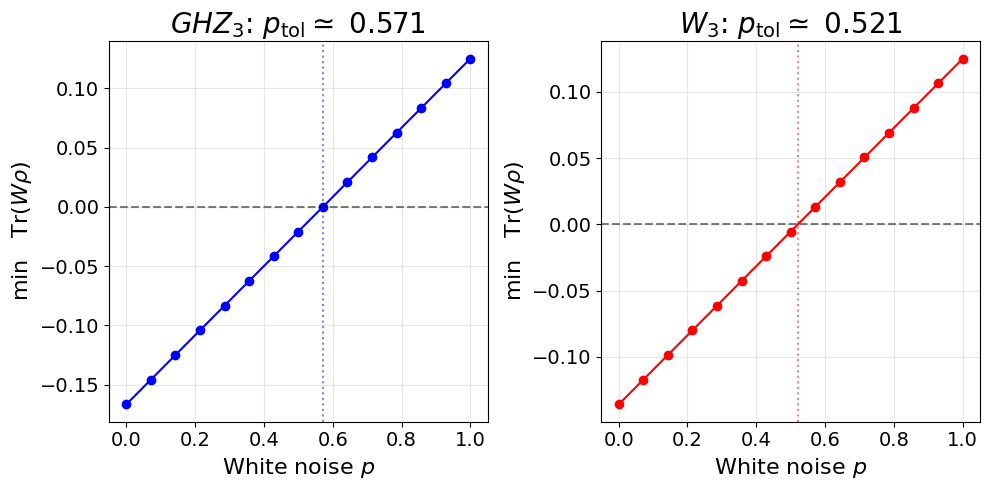

In [95]:
# Plot results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(noise_ghz, vals_ghz, 'b-o', label='GHZ₃')
ax[0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax[0].axvline(x=ptol_ghz, color='b', linestyle=':', alpha=0.5)
ax[0].set_xlabel(r'White noise $p$', fontsize=16)
ax[0].set_ylabel(r'$\min \quad \text{Tr}(W\rho)$', fontsize=16)
ax[0].set_title(r'$GHZ_3$: $p_{\text{tol}} \simeq$'+ rf' {ptol_ghz:.3f}', fontsize=20)
ax[0].tick_params(labelsize=14, which="both")
ax[0].grid(True, alpha=0.3)

ax[1].plot(noise_w, vals_w, 'r-o', label='W₃')
ax[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax[1].axvline(x=ptol_w, color='r', linestyle=':', alpha=0.5)
ax[1].set_xlabel(r'White noise $p$', fontsize=16)
ax[1].set_ylabel(r'$\min \quad \text{Tr}(W\rho)$', fontsize=16)
ax[1].set_title(r'$W_3$: $p_{\text{tol}} \simeq$'+ rf' {ptol_w:.3f}', fontsize=20)
ax[1].tick_params(labelsize=14, which="both")
ax[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../Presentation/media/images/Numerical_Result.svg")
fig.savefig("../Presentation/media/images/Numerical_Result.png", dpi=600)

## 6. Entanglement Monotone

The entanglement monotone quantifies how much genuine multipartite entanglement is present.

In [63]:
import time

# Compute entanglement monotone for GHZ and W states from 2 to 5 qubits
max_qubits = 5
qubit_range = range(2, max_qubits + 1)

entmon_ghz = []
entmon_w = []
times_ghz = []
times_w = []

print("Computing entanglement monotones...")
print("-" * 60)
for n in qubit_range:
    print(f"n = {n} qubits:")
    
    # GHZ state
    t_start = time.time()
    em_ghz = entmon(ghz_state(n))
    t_ghz = time.time() - t_start
    entmon_ghz.append(em_ghz)
    times_ghz.append(t_ghz)
    print(f"  GHZ: E = {em_ghz:.4f}  (time: {t_ghz:.3f}s)")
    
    # W state
    t_start = time.time()
    em_w = entmon(w_state(n))
    t_w = time.time() - t_start
    entmon_w.append(em_w)
    times_w.append(t_w)
    print(f"  W:   E = {em_w:.4f}  (time: {t_w:.3f}s)")

print("-" * 60)
print(f"Total time: {sum(times_ghz) + sum(times_w):.2f}s")

Computing entanglement monotones...
------------------------------------------------------------
n = 2 qubits:
  GHZ: E = 0.5000  (time: 0.018s)
  W:   E = 0.5000  (time: 0.015s)
n = 3 qubits:
  GHZ: E = 0.5000  (time: 0.253s)
  W:   E = 0.4428  (time: 0.139s)
n = 4 qubits:
  GHZ: E = 0.5000  (time: 1.410s)
  W:   E = 0.3660  (time: 1.437s)
n = 5 qubits:
  GHZ: E = 0.5000  (time: 15.855s)
  W:   E = 0.3090  (time: 16.719s)
------------------------------------------------------------
Total time: 35.85s


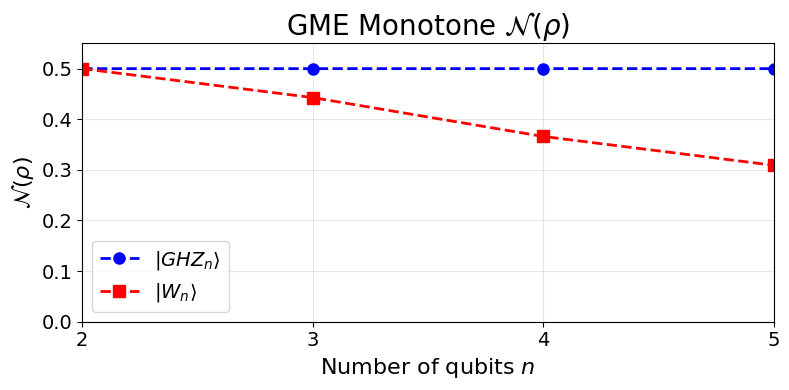

In [89]:
# Plot entanglement monotone vs number of qubits
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(qubit_range), entmon_ghz, 'b--o', label=r'$|GHZ_n\rangle$', markersize=8, linewidth=2)
ax.plot(list(qubit_range), entmon_w, 'r--s', label=r'$|W_n\rangle$', markersize=8, linewidth=2)

ax.set_xlabel('Number of qubits $n$', fontsize=16)
ax.set_ylabel(r'$\mathcal{N}(\rho)$', fontsize=16)
ax.set_title(r'GME Monotone $\mathcal{N}(\rho)$', fontsize=20)
ax.tick_params(labelsize=14, which="both")
ax.set_xticks(list(qubit_range))

ax.set_ylim(0, 0.55)
ax.set_xlim(2, 5)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)


plt.tight_layout()
fig.savefig("../Presentation/media/images/Entanglement_Monotone_Scaling.svg")
fig.savefig("../Presentation/media/images/Entanglement_Monotone_Scaling.png", dpi=600)
plt.show()

### Entanglement Monotone vs White Noise (Bell State)

Let's see how the entanglement monotone degrades as we add white noise to a Bell state.

In [65]:
# Compute entanglement monotone vs white noise for Bell state
rho_bell = bell_state('phi+')
noise_levels = np.linspace(0, 1, 100)

entmon_bell_noise = np.zeros_like(noise_levels)

for i, p in enumerate(noise_levels):
    rho_noisy = add_white_noise(rho_bell, p)
    em = entmon(rho_noisy)
    entmon_bell_noise[i] = em

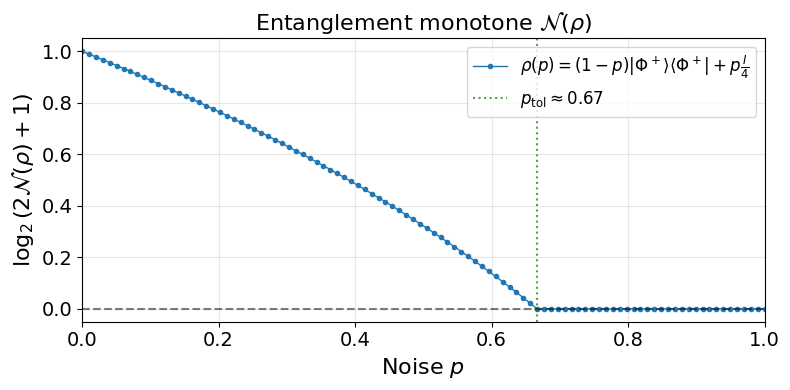

In [92]:
# Plot entanglement monotone vs white noise for Bell state
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(noise_levels, np.log2(2*entmon_bell_noise+1), linestyle="-", markersize=3, linewidth=1, label=r'$\rho (p) = (1-p)|\Phi^+ \rangle\langle\Phi^+ | + p\frac{I}{4}$', marker="o")
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)

ax.axvline(x=2/3, color='g', linestyle=':', alpha=0.7, 
            label=f'$p_{{\\text{{tol}}}} \\approx {2/3:.2f}$')


ax.set_xlabel(r'Noise $p$', fontsize=16)
ax.set_ylabel(r'$\log_2 (2\mathcal{N}(\rho)+1)$', fontsize=16)
ax.set_title(r'Entanglement monotone $\mathcal{N}(\rho)$', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=14, which="both")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
fig.savefig("../Presentation/media/images/Bell_Entanglement_vs_Noise.svg")
fig.savefig("../Presentation/media/images/Bell_Entanglement_vs_Noise.png", dpi=600)
plt.show()

## 7. Four-Qubit Dicke State

The Dicke state |D_{2,4}> has 2 excitations among 4 qubits.

In [67]:
# Create Dicke state
rho_dicke = dicke_state(4, 2)
print(rho_dicke)

# This takes longer due to more bipartitions
min_val, W = fdecwit(rho_dicke)
print(f"Minimum value: {min_val:.3f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

noise_D42, vals_D42, ptol_D42 = find_noise_tolerance(rho_dicke, "Dicke_4,2", 15)
print(f"Dicke_4,2 noise tolerance: p_tol = {ptol_D42:.3f}")

[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.    +0.j 0.1667+0.j
  0.1667+0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.1667+0.j 0.    +0.j
  0.1667+0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.    +0.j 0.1667+0.j
  0.1667+0.j 0.  

In [71]:
test = np.array([
[0 , 0 , 0 , 0 ],
[ 0 , 1 , -1 , 0 ], 
[ 0 , -1 , 1 , 0 ], 
[0 , 0 , 0 , 0 ],
])
np.linalg.eigvals(test)

array([2., 0., 0., 0.])